In [61]:
%pip install -q transformers torch pandas matplotlib seaborn requests tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
from IPython.display import Markdown, display
from ipywidgets import Dropdown, interact
from tqdm.auto import tqdm
from transformers import pipeline

pd.set_option("display.max_columns", 160)
sns.set_theme(style = "whitegrid")
print("PyTorch:", torch.__version__)
print("CUDA-GPU tilgængelig:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
CUDA-GPU tilgængelig: False


In [2]:
TEXT_URL = "https://www.gutenberg.org/cache/epub/97/pg97.txt"
TEXT_FILE = Path("flatland.txt")
if not TEXT_FILE.exists():
    response = requests.get(TEXT_URL, timeout=30)
    response.raise_for_status()
    TEXT_FILE.write_text(response.text, encoding="utf-8")
raw_text = TEXT_FILE.read_text(encoding="utf-8")
print(f"Indlæst {len(raw_text):,} tegn")
print(raw_text[:300])

Indlæst 213,450 tegn
The Project Gutenberg eBook of Flatland: A Romance of Many Dimensions
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Proj


In [3]:
def extract_book(text):
    start = text.find("§ 1 Of the Nature of Flatland")
    end = text.find("*** END OF THE PROJECT GUTENBERG EBOOK")
    if start == -1:
        raise ValueError("Kunne ikke finde første afsnit")
    return text[start:end if end != -1 else None]


def parse_sections(text):
    heading = re.compile(r"^§\s*(\d+)\s+(.+)$")
    records = []
    number = None
    title = None
    buffer = []

    def save():
        nonlocal buffer, number, title
        if number is not None and title is not None:
            body = "\n".join(buffer)
            body = re.sub(r"\[Illustration.*?\]", " ", body, flags=re.I | re.S)
            body = re.sub(r"[ \t]+", " ", body)
            body = re.sub(r"\n{3,}", "\n\n", body).strip()
            records.append(
                {
                    "section": number,
                    "title": title.strip(),
                    "part": "I — This World" if number <= 12 else "II — Other Worlds",
                    "text": body,
                }
            )
        buffer = []

    lines = text.splitlines()
    i = 0

    while i < len(lines):
        line = lines[i].strip()
        match = heading.match(line)

        if match:
            save()
            number = int(match.group(1))
            title = match.group(2)

            # Nogle lange overskrifter fortsætter på næste linje.
            while i + 1 < len(lines):
                nxt = lines[i + 1].strip()
                if not nxt or heading.match(nxt):
                    break
                title += " " + nxt
                i += 1

        elif number is not None:
            buffer.append(line)

        i += 1

    save()

    df = pd.DataFrame(records)
    df["word_count"] = df["text"].str.split().apply(len)
    return df


book_text = extract_book(raw_text)
sections = parse_sections(book_text)
print(f"Fandt {len(sections)} afsnit og {sections.word_count.sum():,} ord")
sections[["section", "part", "title", "word_count"]]

Fandt 22 afsnit og 33,244 ord


,section,part,title,word_count
0,1,I — This World,Of the Nature of Flatland,731
1,2,I — This World,Of the Climate and Houses in Flatland,807
2,3,I — This World,Concerning the Inhabitants of Flatland,1218
3,4,I — This World,Concerning the Women,1899
4,5,I — This World,Of our Methods of Recognizing one another,1763
5,6,I — This World,Of Recognition by Sight,1742
6,7,I — This World,Concerning Irregular Figures,1216
7,8,I — This World,Of the Ancient Practice of Painting,974
8,9,I — This World,Of the Universal Colour Bill,1293
9,10,I — This World,Of the Suppression of the Chromatic Sedition,1449


In [4]:
def make_passages(section_df, words_per_passage = 120):
    rows = []
    passage_id = 1
    for section in section_df.itertuples():
        words = section.text.split()
        for start in range (0, len(words), words_per_passage):
            chunk = " ".join(words[start:start + words_per_passage])
            if len(chunk.split()) < 30:
                continue
            rows.append({
                "passage_id": passage_id,
                "section": section.section,
                "part":section.part,
                "title":section.title,
                "text": chunk,
            })
            passage_id += 1
    result = pd.DataFrame(rows)
    result["position"] = np.linspace(0, 100, len(result))
    result["word_count"] = result.text.str.split().str.len()
    return result
passages = make_passages(sections)
print(f"Oprettet {len(passages)} analysepassager")
passages.head()

Oprettet 282 analysepassager


,passage_id,section,part,title,text,position,word_count
0,1,1,I — This World,Of the Nature of Flatland,"I call our world Flatland, not because we call...",0.000000,120
1,2,1,I — This World,Of the Nature of Flatland,you will perceive at once that it is impossibl...,0.355872,120
2,3,1,I — This World,Of the Nature of Flatland,"back to the edge of the table, gradually lower...",0.711744,120
3,4,1,I — This World,Of the Nature of Flatland,look at it with your eye on the edge of the ta...,1.067616,120
4,5,1,I — This World,Of the Nature of Flatland,nothing but a straight line. When I was in Spa...,1.423488,120


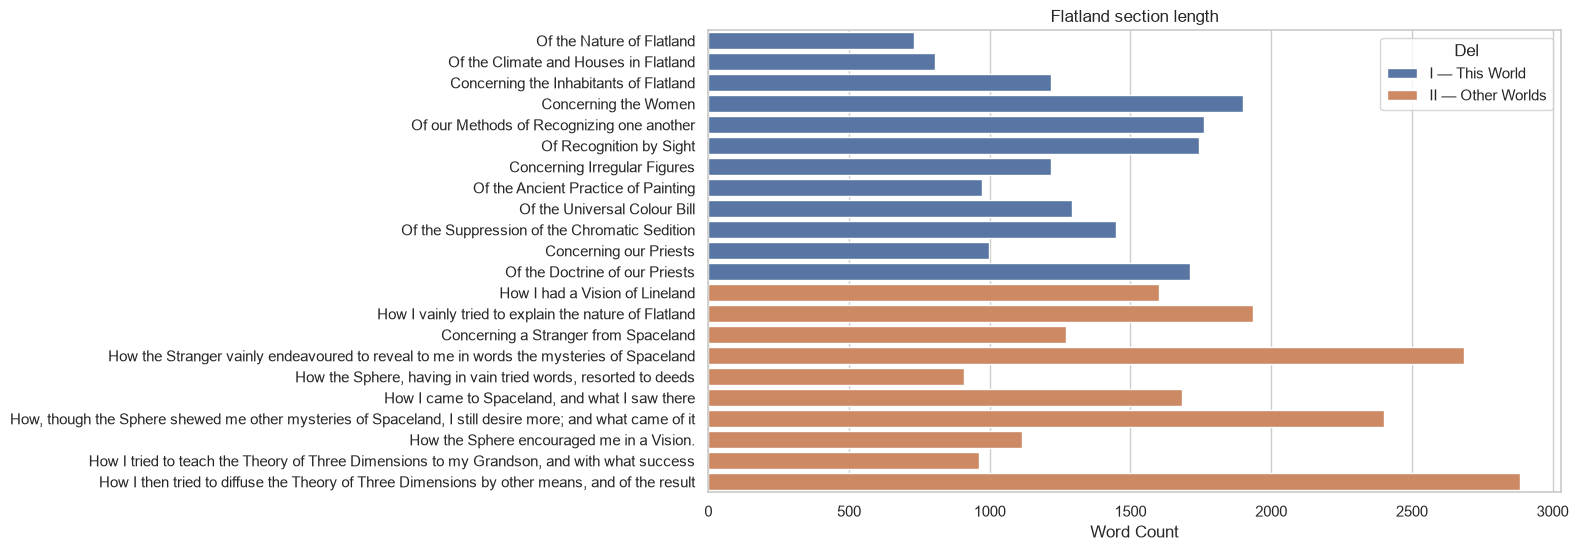

In [5]:
plt.figure(figsize=(11,6))
sns.barplot(data = sections, x="word_count",y="title",hue="part", dodge=False)
plt.title("Flatland section length")
plt.xlabel("Word Count")
plt.ylabel("")
plt.legend(title="Del")
plt.show()

In [6]:
MODEL_NAME = "valhalla/distilbart-mnli-12-1"
classifier = pipeline(
    "zero-shot-classification",
    model = MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
)
print("Modellen er klar:", MODEL_NAME)

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

Modellen er klar: valhalla/distilbart-mnli-12-1


In [13]:
DEFAULT_THEMES = [
    "reality and perception",
    "knowledge and enlightenment",
    "social control",
    "freedom and rebellion",
    "class hierarchy",
    "identity",
    "resistance to new ideas"
]

def classify_text(text, labels=DEFAULT_THEMES):
    shortened = " ".join(text.split()[:250])
    output = classifier(
        shortened,
        candidate_labels = list(labels),
        multi_label=True,
        hypothesis_template = "This passage is about {}.",
    )
    return pd.DataFrame({"theme": output["labels"], "score": output["scores"]})

example = passages.query("section == 17").iloc[0]
display(Markdown(f"### §{example.section}: {example.title}"))
display(Markdown(f"> {example.text}"))
example_scores = classify_text(example.text)
display(example_scores.style.format({"score": "{:.1%}"}).bar(
    subset=["score"], vmin=0, vmax=1, color="#7a9cc6"
))

### §17: How the Sphere, having in vain tried words, resorted to deeds

> It was in vain. I brought my hardest right angle into violent collision with the Stranger, pressing on him with a force sufficient to have destroyed any ordinary Circle: but I could feel him slowly and unarrestably slipping from my contact; not edging to the right nor to the left, but moving somehow out of the world, and vanishing into nothing. Soon there was a blank. But still I heard the Intruder’s voice. _Sphere_. Why will you refuse to listen to reason? I had hoped to find in you—as being a man of sense and an accomplished mathematician—a fit apostle for the Gospel of the Three Dimensions, which I am allowed to preach once only in a thousand years: but

,theme,score
0,knowledge and enlightenment,16.3%
1,freedom and rebellion,7.1%
2,identity,5.6%
3,resistance to new ideas,5.3%
4,social control,4.7%
5,reality and perception,4.4%
6,class hierarchy,2.5%


In [14]:
section_options = [
    (f"§{row.section}: {row.title}", int(row.section))
    for row in sections.itertuples()
]

def explore_section(section_number):
    choices = passages.query("section == @section_number").copy()
    choices["menu_text"] = choices.apply(
        lambda r: f"Passage {r.passage_id}: {r.text[:95]}…", axis=1
    )
    menu = Dropdown(
        options=[(r.menu_text, int(r.passage_id)) for _, r in choices.iterrows()],
        description="Passage:",
        layout={"width": "95%"}
    )
    

    def show(passage_id):
        row = passages.loc[passages.passage_id == passage_id].iloc[0]
        display(Markdown(f"### §{row.section}: {row.title}"))
        display(Markdown(f"> {row.text}"))
        result = classify_text(row.text)
        display(result.style.format({"score": "{:.1%}"}).bar(
        subset=["score"], vmin=0, vmax=1, color="#7a9cc6"
    ))

    interact(show, passage_id=menu)

interact(
    explore_section,
    section_number=Dropdown(options=section_options, value=15, description="Afsnit:"),
)


interactive(children=(Dropdown(description='Afsnit:', index=14, options=(('§1: Of the Nature of Flatland', 1),…

<function __main__.explore_section(section_number)>

In [15]:
PASSAGES_PER_SECTION = 2
sample_parts = []
for _, group in passages.groupby("section"):
    indices = np.linspace(0, len(group) - 1, min(PASSAGES_PER_SECTION, len(group))).astype(int)
    sample_parts.append(group.iloc[indices])
sample = pd.concat(sample_parts, ignore_index=True).drop_duplicates("passage_id")

classified_rows = []
for row in tqdm(sample.itertuples(), total=len(sample)):
    result = classify_text(row.text)
    scores = dict(zip(result.theme, result.score))
    classified_rows.append({
        "passage_id": row.passage_id,
        "section": row.section,
        "part": row.part,
        "title": row.title,
        "position": row.position,
        "text": row.text,
        **scores,
})
classified = pd.DataFrame(classified_rows)
classified.head()

  0%|          | 0/44 [00:00<?, ?it/s]

,passage_id,section,part,title,position,text,reality and perception,knowledge and enlightenment,identity,freedom and rebellion,resistance to new ideas,class hierarchy,social control
0,1,1,I — This World,Of the Nature of Flatland,0.000000,"I call our world Flatland, not because we call...",0.296379,0.126438,0.108356,0.098222,0.054554,0.032830,0.024754
1,6,1,I — This World,Of the Nature of Flatland,1.779359,"a kind as to make shadows, we have none of the...",0.386955,0.088038,0.321897,0.192728,0.138529,0.077608,0.179592
2,7,2,I — This World,Of the Climate and Houses in Flatland,2.135231,"As with you, so also with us, there are four p...",0.262536,0.293323,0.184899,0.189436,0.117143,0.075180,0.052400
3,13,2,I — This World,Of the Climate and Houses in Flatland,4.270463,"special tax. But, about three centuries afterw...",0.400910,0.199931,0.338473,0.069300,0.115364,0.181238,0.450668
4,14,3,I — This World,Concerning the Inhabitants of Flatland,4.626335,The greatest length or breadth of a full grown...,0.532337,0.432222,0.526168,0.299156,0.268933,0.591649,0.371031


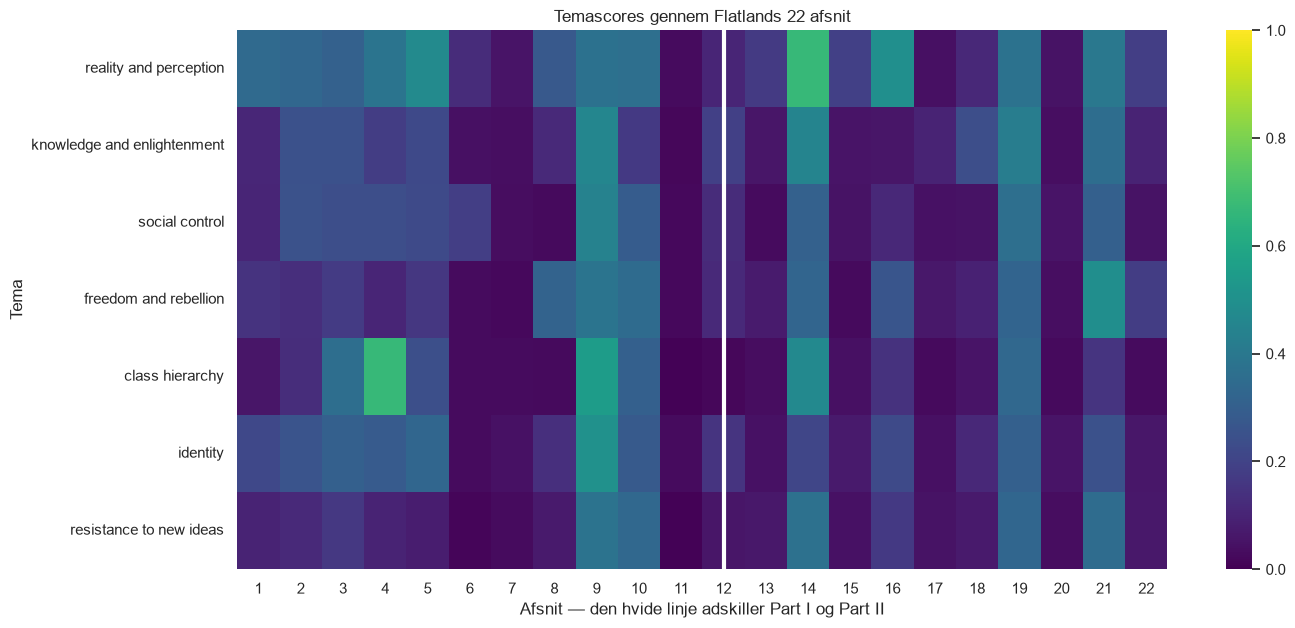

In [16]:
section_scores = classified.groupby("section")[DEFAULT_THEMES].mean()
plt.figure(figsize=(15, 7))
sns.heatmap(section_scores.T, cmap="viridis", vmin=0, vmax=1)
plt.axvline(11.5, color="white", linewidth=3)
plt.title("Temascores gennem Flatlands 22 afsnit")
plt.xlabel("Afsnit — den hvide linje adskiller Part I og Part II")
plt.ylabel("Tema")
plt.show()

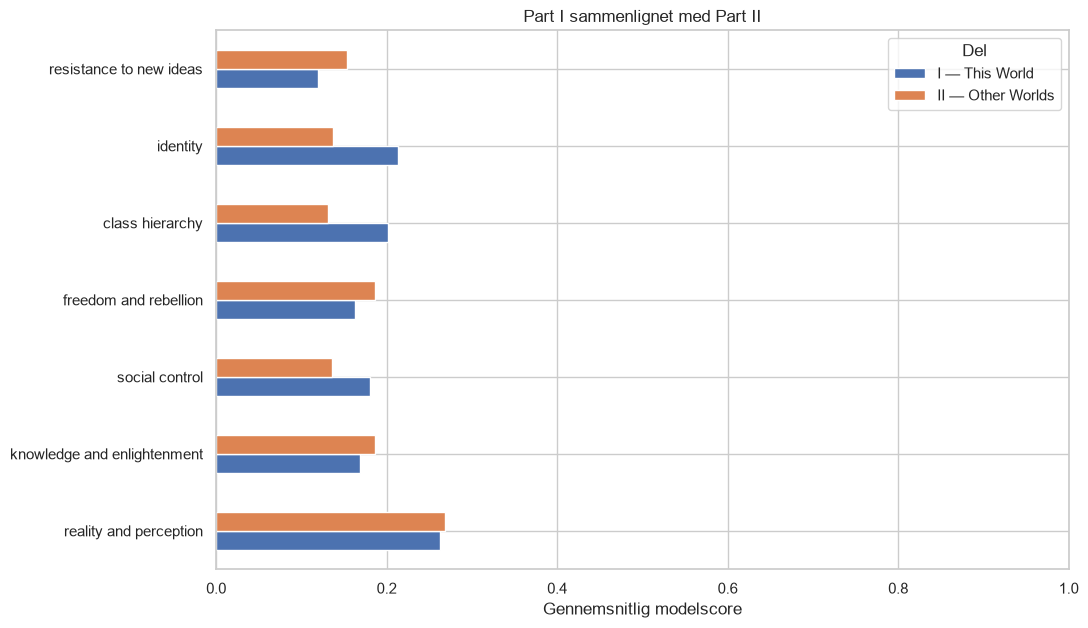

In [17]:
part_scores = classified.groupby("part")[DEFAULT_THEMES].mean().T
part_scores.plot(kind="barh", figsize=(11, 7))
plt.xlim(0, 1)
plt.title("Part I sammenlignet med Part II")
plt.xlabel("Gennemsnitlig modelscore")
plt.ylabel("")
plt.legend(title="Del")
plt.show()

In [18]:
def strongest_passages(theme, n=5):
    columns = ["section", "title", "text", theme]
    return (
    classified[columns]
    .sort_values(theme, ascending=False)
    .head(n)
    .style.format({theme: "{:.1%}"})
)
strongest_passages("reality and perception")

,section,title,text,reality and perception
26,14,How I vainly tried to explain the nature of Flatland,"Thinking that it was time to bring down the Monarch from his raptures to the level of common sense, I determined to endeavour to open up to him some glimpses of the truth, that is to say of the nature of things in Flatland. So I began thus: “How does your Royal Highness distinguish the shapes and positions of his subjects? I for my part noticed by the sense of sight, before I entered your Kingdom, that some of your people are lines and others Points; and that some of the lines are larger—” “You speak of an impossibility,” interrupted the King; “you must have seen a vision; for to detect the difference between a Line and a Point by",80.8%
41,21,"How I tried to teach the Theory of Three Dimensions to my Grandson, and with what success","I, losing my temper; “here for example, I take this Square,” and, at the word, I grasped a moveable Square, which was lying at hand—“and I move it, you see, not Northward but—yes, I move it Upward—that is to say, Northward but I move it somewhere—not exactly like this, but somehow—” Here I brought my sentence to an inane conclusion, shaking the Square about in a purposeless manner, much to the amusement of my Grandson, who burst out laughing louder than ever, and declared that I was not teaching him, but joking with him; and so saying he unlocked the door and ran out of the room. Thus ended my first attempt to convert a pupil to the Gospel of",66.2%
31,16,How the Stranger vainly endeavoured to reveal to me in words the mysteries of Spaceland,"to say, six of your insides. You see it all now, eh? “Monster,” I shrieked, “be thou juggler, enchanter, dream, or devil, no more will I endure thy mockeries. Either thou or I must perish.” And saying these words I precipitated myself upon him.",62.8%
18,10,Of the Suppression of the Chromatic Sedition,"The agitation for the Universal Colour Bill continued for three years; and up to the last moment of that period it seemed as though Anarchy were destined to triumph. A whole army of Polygons, who turned out to fight as private soldiers, was utterly annihilated by a superior force of Isosceles Triangles—the Squares and Pentagons meanwhile remaining neutral. Worse than all, some of the ablest Circles fell a prey to conjugal fury. Infuriated by political animosity, the wives in many a noble household wearied their lords with prayers to give up their opposition to the Colour Bill; and some, finding their entreaties fruitless, fell on and slaughtered their innocent children and husband, perishing themselves in the act of carnage. It",60.1%
8,5,Of our Methods of Recognizing one another,"You, who are blessed with shade as well as light, you, who are gifted with two eyes, endowed with a knowledge of perspective, and charmed with the enjoyment of various colours, you, who can actually _see_ an angle, and contemplate the complete circumference of a Circle in the happy region of the Three Dimensions—how shall I make it clear to you the extreme difficulty which we in Flatland experience in recognizing one another’s configuration? Recall what I told you above. All beings in Flatland, animate and inanimate, no matter what their form, present _to our view_ the same, or nearly the same, appearance, viz. that of a straight Line. How then can one be distinguished from another, where all appear",56.1%


In [19]:
comparison = pd.DataFrame([
    {"Flatland": "Square", "The Matrix": "Neo", "Funktion": "Personen, hvis virkelighedsopfattelse bryder sammen"},
    {"Flatland": "Sphere", "The Matrix": "Morpheus", "Funktion": "Mentoren, der afslører en større virkelighed"},
    {"Flatland": "Spaceland", "The Matrix": "Den virkelige verden", "Funktion": "Virkelighed uden for den kendte verden"},
    {"Flatland": "Priests og Circles", "The Matrix": "Agents og maskiner", "Funktion": "Systemet, der beskytter den gældende orden"},
    {"Flatland": "Tredje dimension", "The Matrix": "Afsløringen af simulationen", "Funktion": "Viden, som ændrer alt"},
])
comparison

,Flatland,The Matrix,Funktion
0,Square,Neo,"Personen, hvis virkelighedsopfattelse bryder s..."
1,Sphere,Morpheus,"Mentoren, der afslører en større virkelighed"
2,Spaceland,Den virkelige verden,Virkelighed uden for den kendte verden
3,Priests og Circles,Agents og maskiner,"Systemet, der beskytter den gældende orden"
4,Tredje dimension,Afsløringen af simulationen,"Viden, som ændrer alt"


In [ ]:
passage = passages.query("section == 2").iloc[0].text
matrix_labels = ["awakening", "false reality", "mentor", "freedom", "sphere", "orb"]
social_labels = ["class discrimination", "gender inequality", "authority", "conformity"]
display(Markdown(f"> {passage}"))
display(Markdown("### Matrix-inspirerede labels"), classify_text(passage, matrix_labels))
display(Markdown("### Samfundskritiske labels"), classify_text(passage, social_labels))

> As with you, so also with us, there are four points of the compass North, South, East, and West. There being no sun nor other heavenly bodies, it is impossible for us to determine the North in the usual way; but we have a method of our own. By a Law of Nature with us, there is a constant attraction to the South; and, although in temperate climates this is very slight—so that even a Woman in reasonable health can journey several furlongs northward without much difficulty—yet the hampering effort of the southward attraction is quite sufficient to serve as a compass in most parts of our earth. Moreover, the rain (which falls at stated intervals) coming always from the

### Matrix-inspirerede labels

,theme,score
0,mentor,0.637423
1,awakening,0.201215
2,sphere,0.198190
3,freedom,0.099167
4,false reality,0.067816


### Samfundskritiske labels

,theme,score
0,authority,0.149061
1,conformity,0.128147
2,gender inequality,0.109171
3,class discrimination,0.074168


1 Den røde pille: Find det øjeblik i Flatland, der bedst svarer til Neos opvågning. Begrund valget med tekstbevis.
2 Mentoren: Sammenlign Sphere og Morpheus. Hjælper de hovedpersonen af samme grund?
3 Modellens fejl: Find en passage, hvor den højeste temascore er misvisende. Forklar hvorfor.
4 Labels som bias: Udskift social control med social stability. Hvordan ændres scoren og
fortolkningen?
5 Part I mod Part II: Hvilke temaer ændrer sig mest, da fortællingen går fra samfundsbeskrivelse til
erkendelsesrejse?
6 Menneske mod model: Lad elevgrupper mærke ti passager og sammenlign deres vurderinger med modellen.